## Задание

Распознайте рукописную цифру, написанную на листе от руки.
Последовательность шагов следующая:

*   На бумаге рисуем произвольную цифру (желательно нарисовать цифру размером не
более 5 * 5 мм и без наклона. В занятии нейронка обучалась на цифрах американских студентов. Эти цифры были написаны на тетрадных листах в клетку и имели схожий размер).
*   Фотографируем. Загружаем фото в Collaboratory.
*   С помощью функции image.load_img(path, target_size=(28, 28), color_mode = ‘grayscale’) загружаем картинку в переменную.
*   С помощью функции image.img_to_array(img) преобразуем изображение в numpy-массив.
*   Выполняем инверсию цветов, нормирование и решейп массива.
*   Выполняем распознавание собственной рукописной цифры.

Примечание: точность распознавания рукописных цифр может быть достаточно низкой, т.к. рукописные цифры после преобразований хоть и похожи на содержащиеся в базе, но могут отличаться по конфигурации, толщине линий и т.д.


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import os
import gdown
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)

Версия TensorFlow: 2.19.0


In [49]:
# Загружаем MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация (пиксели от 0 до 1)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encoding для меток
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Обучающая выборка: {x_train.shape}")
print(f"Тестовая выборка: {x_test.shape}")

Обучающая выборка: (60000, 28, 28)
Тестовая выборка: (10000, 28, 28)


In [50]:
# Простая и эффективная модель
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Ранняя остановка для предотвращения переобучения
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Обучение
history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Проверка на официальном тесте MNIST
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nТочность на тесте MNIST: {test_acc:.4f} ({test_acc*100:.1f}%)")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8071 - loss: 0.6999 - val_accuracy: 0.9435 - val_loss: 0.2076
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9446 - loss: 0.1964 - val_accuracy: 0.9569 - val_loss: 0.1564
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9601 - loss: 0.1405 - val_accuracy: 0.9625 - val_loss: 0.1304
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9690 - loss: 0.1057 - val_accuracy: 0.9667 - val_loss: 0.1149
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9761 - loss: 0.0852 - val_accuracy: 0.9690 - val_loss: 0.1068
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9804 - loss: 0.0694 - val_accuracy: 0.9701 - val_loss: 0.1000
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9829 - loss: 0.0598 - val_accuracy: 0.9717 - val_loss: 0.0936
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9871 - loss: 0.0469 - val_accuracy: 0

In [52]:
# Скачиваем и распаковываем твой архив
url = 'https://drive.google.com/uc?id=1VtKeGdn6PdOMl245sWSbVl39otp65XC-'
gdown.download(url, 'num.zip', quiet=False)
!unzip -o -q num.zip -d num_paint

print("Загруженные файлы:")
!ls num_paint

Downloading...
From: https://drive.google.com/uc?id=1VtKeGdn6PdOMl245sWSbVl39otp65XC-
To: /content/num.zip
100%|██████████| 36.4k/36.4k [00:00<00:00, 24.5MB/s]


Загруженные файлы:
0.jpg  1.jpg  2.jpg  3.jpg  4.jpg  5.jpg  6.jpg  7.jpg	8.jpg  9.jpg


In [53]:
def load_and_prepare(image_path):
    """Загружает изображение, подготавливает его для модели."""
    img = image.load_img(image_path, target_size=(28, 28), color_mode='grayscale')
    img_array = image.img_to_array(img)

    # Инверсия, так как MNIST ожидает белую цифру на черном фоне
    img_array = 255 - img_array

    # Нормализация
    img_array = img_array / 255.0

    # Убираем лишнее измерение канала (оно не нужно для нашей модели с Flatten)
    img_array = img_array.reshape(28, 28)

    return img_array

In [54]:
image_dir = 'num_paint'
results = []
images_for_display = []
filenames = []

for i in range(10):
    filename = f"{i}.jpg"
    img_path = os.path.join(image_dir, filename)

    if os.path.exists(img_path):
        # Загружаем и подготавливаем изображение
        img_processed = load_and_prepare(img_path)

        # Модель ожидает батч изображений, поэтому добавляем измерение
        img_batch = img_processed.reshape(1, 28, 28)

        # Предсказание
        prediction = model.predict(img_batch, verbose=0)[0]
        predicted_digit = np.argmax(prediction)
        confidence = prediction[predicted_digit]

        results.append({
            'Истина': i,
            'Предсказано': predicted_digit,
            'Уверенность': confidence,
            'Верно': (i == predicted_digit)
        })
        images_for_display.append(img_processed)
        filenames.append(filename)
    else:
        print(f"Файл {filename} не найден!")

print("Предсказания получены.")

Предсказания получены.


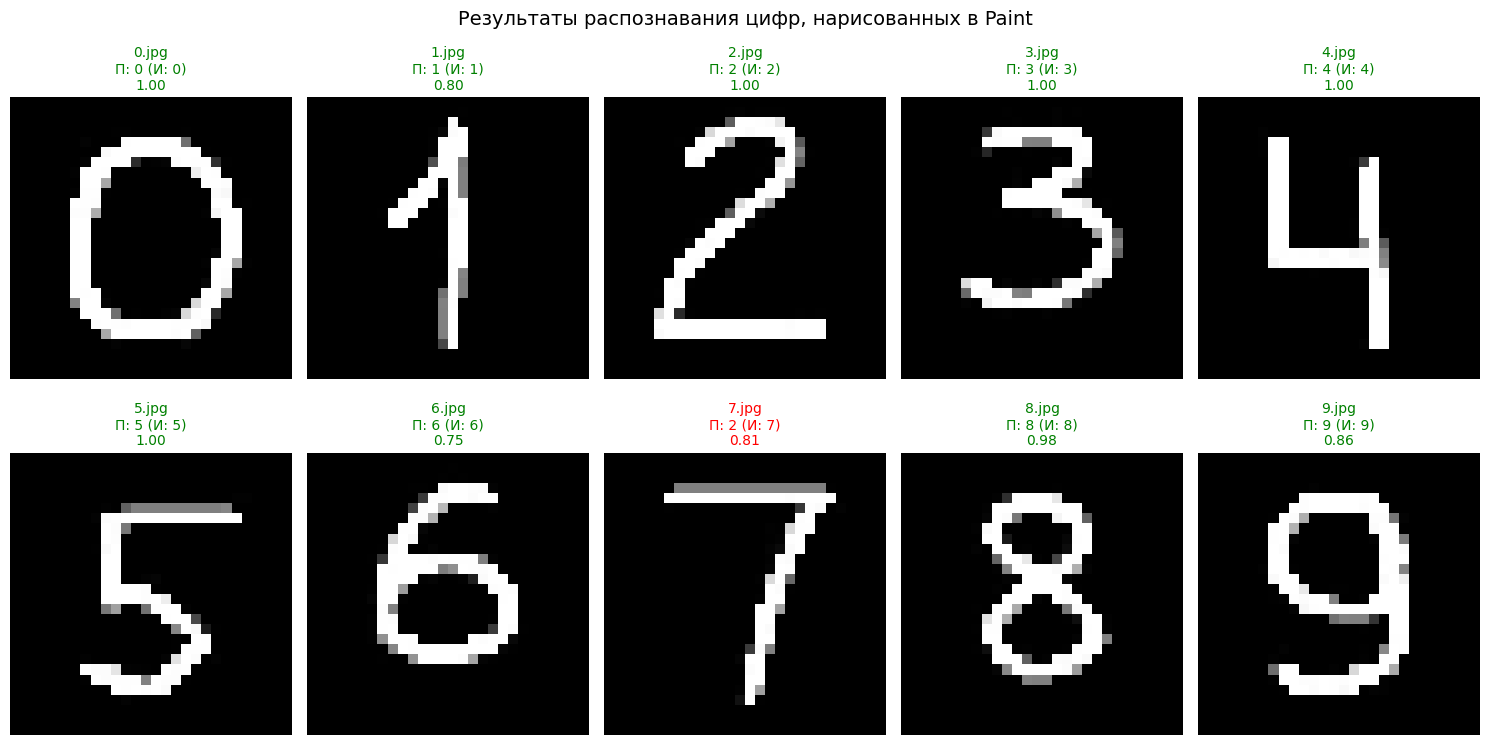

In [56]:
plt.figure(figsize=(15, 8))
for idx, (img, res) in enumerate(zip(images_for_display, results)):
    plt.subplot(2, 5, idx+1)
    plt.imshow(img, cmap='gray')
    color = 'green' if res['Верно'] else 'red'
    plt.title(f"{filenames[idx]}\nП: {res['Предсказано']} (И: {res['Истина']})\n{res['Уверенность']:.2f}",
              color=color, fontsize=10)
    plt.axis('off')
plt.suptitle('Результаты распознавания цифр, нарисованных в Paint', fontsize=14)
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd
df_results = pd.DataFrame(results)
print("Итоговая таблица:")
print(df_results.to_string(index=False))

accuracy = df_results['Верно'].sum() / len(df_results) * 100
print(f"\nОбщая точность: {accuracy:.1f}% ({df_results['Верно'].sum()}/{len(df_results)})")

Итоговая таблица:
 Истина  Предсказано  Уверенность  Верно
      0            0     0.999975   True
      1            1     0.802115   True
      2            2     0.997476   True
      3            3     0.999234   True
      4            4     0.999990   True
      5            5     0.999857   True
      6            6     0.751946   True
      7            2     0.806421  False
      8            8     0.982387   True
      9            9     0.863805   True

Общая точность: 90.0% (9/10)
